In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


One-hot encoded F1 dataset:
    1-Stop  2-Stop  Cloudy  FastestLap   Hard  Medium  Overtake   Pole   Rain  \
0    True   False   False        True  False   False      True  False  False   
1   False    True    True       False  False    True      True  False  False   
2    True   False   False        True   True   False     False   True  False   
3   False    True   False       False  False   False     False  False   True   
4    True   False   False       False  False    True      True  False  False   
5   False    True    True       False   True   False     False   True  False   
6    True   False   False       False  False   False      True   True  False   
7   False    True   False       False  False    True     False  False   True   
8    True   False   False        True   True   False     False  False  False   
9   False    True    True       False  False   False      True  False  False   

   SafetyCar   Soft  Sunny  
0      False   True   True  
1       True  False  False  
2  

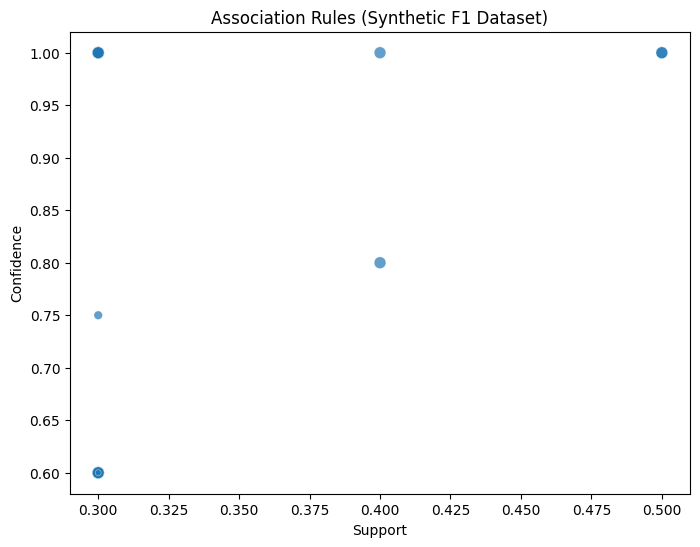

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

# -----------------------------
# 1. Create synthetic F1 race dataset (transactions)
# -----------------------------
transactions = [
    ["Soft", "1-Stop", "Sunny", "Overtake", "FastestLap"],
    ["Medium", "2-Stop", "Cloudy", "SafetyCar", "Overtake"],
    ["Hard", "1-Stop", "Sunny", "Pole", "FastestLap"],
    ["Soft", "2-Stop", "Rain", "SafetyCar"],
    ["Medium", "1-Stop", "Sunny", "Overtake"],
    ["Hard", "2-Stop", "Cloudy", "Pole"],
    ["Soft", "1-Stop", "Sunny", "Overtake", "Pole"],
    ["Medium", "2-Stop", "Rain", "SafetyCar"],
    ["Hard", "1-Stop", "Sunny", "FastestLap"],
    ["Soft", "2-Stop", "Cloudy", "Overtake", "SafetyCar"]
]

# -----------------------------
# 2. Convert to one-hot encoding
# -----------------------------
items = sorted({item for t in transactions for item in t})
data = pd.DataFrame([{item: (item in t) for item in items} for t in transactions])

print("One-hot encoded F1 dataset:\n", data)

# -----------------------------
# 3. Apply Apriori Algorithm
# -----------------------------
frequent_itemsets = apriori(data, min_support=0.3, use_colnames=True)
print("\nFrequent Itemsets:\n", frequent_itemsets)

# -----------------------------
# 4. Generate Association Rules
# -----------------------------
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print("\nAssociation Rules:\n", rules[["antecedents", "consequents", "support", "confidence", "lift"]])

# -----------------------------
# 5. Visualization - Support vs Confidence
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x="support", y="confidence", size="lift", data=rules, legend=False, alpha=0.7)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules (Synthetic F1 Dataset)")
plt.show()


In [ ]:
# -----------------------------
# 2. Apply Apriori algorithm on F1 synthetic dataset
# -----------------------------
frequent_itemsets = apriori(data, min_support=0.3, use_colnames=True)

print("\nFrequent Itemsets:\n", frequent_itemsets)


Frequent Itemsets:
     support                     itemsets
0       0.5                     (1-Stop)
1       0.5                     (2-Stop)
2       0.3                     (Cloudy)
3       0.3                 (FastestLap)
4       0.3                       (Hard)
5       0.3                     (Medium)
6       0.5                   (Overtake)
7       0.3                       (Pole)
8       0.4                  (SafetyCar)
9       0.4                       (Soft)
10      0.5                      (Sunny)
11      0.3         (FastestLap, 1-Stop)
12      0.3           (1-Stop, Overtake)
13      0.5              (Sunny, 1-Stop)
14      0.3             (2-Stop, Cloudy)
15      0.4          (2-Stop, SafetyCar)
16      0.3          (Sunny, FastestLap)
17      0.3             (Soft, Overtake)
18      0.3            (Sunny, Overtake)
19      0.3  (Sunny, FastestLap, 1-Stop)
20      0.3    (Sunny, 1-Stop, Overtake)


In [ ]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print("\nAssociation Rules:\n", rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Association Rules:
              antecedents           consequents  support  confidence  lift
0           (FastestLap)              (1-Stop)      0.3        1.00   2.0
1               (1-Stop)          (FastestLap)      0.3        0.60   2.0
2               (1-Stop)            (Overtake)      0.3        0.60   1.2
3             (Overtake)              (1-Stop)      0.3        0.60   1.2
4                (Sunny)              (1-Stop)      0.5        1.00   2.0
5               (1-Stop)               (Sunny)      0.5        1.00   2.0
6               (2-Stop)              (Cloudy)      0.3        0.60   2.0
7               (Cloudy)              (2-Stop)      0.3        1.00   2.0
8               (2-Stop)           (SafetyCar)      0.4        0.80   2.0
9            (SafetyCar)              (2-Stop)      0.4        1.00   2.0
10               (Sunny)          (FastestLap)      0.3        0.60   2.0
11          (FastestLap)               (Sunny)      0.3        1.00   2.0
12               

In [ ]:
# -----------------------------
# 4. Accuracy calculation
# -----------------------------
accuracies = []

for idx, rule in rules.iterrows():
    antecedent = list(rule['antecedents'])
    consequent = list(rule['consequents'])

    # Transactions where antecedent is present
    antecedent_match = data[antecedent].all(axis=1)

    # Transactions where both antecedent and consequent are present
    both_match = data[antecedent + consequent].all(axis=1)

    antecedent_count = antecedent_match.sum()
    if antecedent_count > 0:
        accuracy = both_match.sum() / antecedent_count
    else:
        accuracy = 0

    accuracies.append(accuracy)

rules['accuracy'] = accuracies
avg_accuracy = sum(accuracies) / len(accuracies)

print("\nRules with Accuracy:\n",
      rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'accuracy']])
print(f"\nOverall Average Accuracy: {avg_accuracy:.2f}")



Rules with Accuracy:
              antecedents           consequents  support  confidence  lift  \
0           (FastestLap)              (1-Stop)      0.3        1.00   2.0   
1               (1-Stop)          (FastestLap)      0.3        0.60   2.0   
2               (1-Stop)            (Overtake)      0.3        0.60   1.2   
3             (Overtake)              (1-Stop)      0.3        0.60   1.2   
4                (Sunny)              (1-Stop)      0.5        1.00   2.0   
5               (1-Stop)               (Sunny)      0.5        1.00   2.0   
6               (2-Stop)              (Cloudy)      0.3        0.60   2.0   
7               (Cloudy)              (2-Stop)      0.3        1.00   2.0   
8               (2-Stop)           (SafetyCar)      0.4        0.80   2.0   
9            (SafetyCar)              (2-Stop)      0.4        1.00   2.0   
10               (Sunny)          (FastestLap)      0.3        0.60   2.0   
11          (FastestLap)               (Sunny)      0

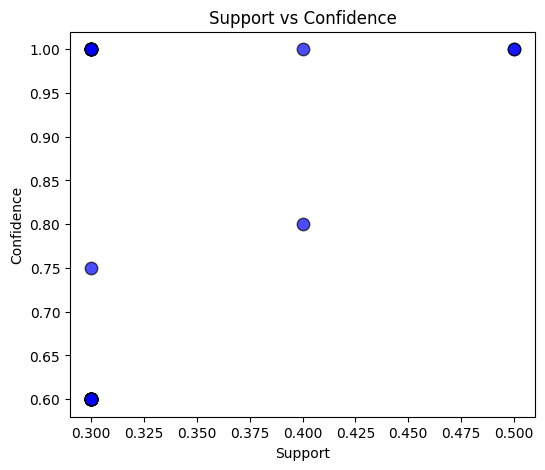

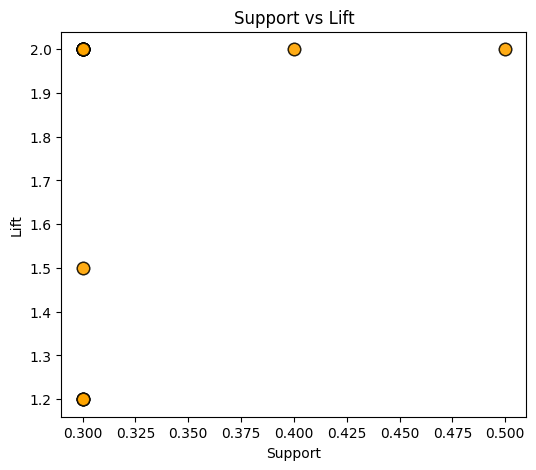

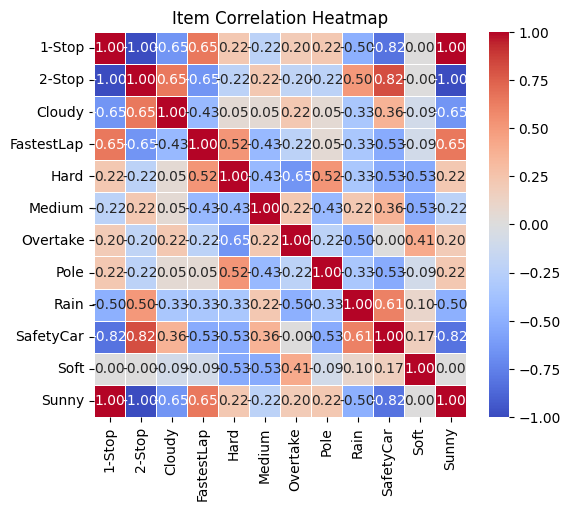

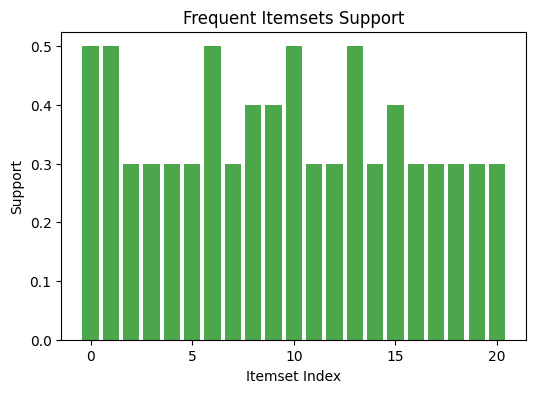

In [ ]:
# -----------------------------
# 5. Visualizations
# -----------------------------

# (a) Scatter plot: Support vs Confidence
plt.figure(figsize=(6,5))
plt.scatter(rules['support'], rules['confidence'], alpha=0.7, s=80, c="blue", edgecolors="k")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# (b) Scatter plot: Support vs Lift
plt.figure(figsize=(6,5))
plt.scatter(rules['support'], rules['lift'], alpha=0.7, s=80, c="orange", edgecolors="k")
plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Support vs Lift")
plt.show()

# (c) Heatmap (like confusion matrix) for item correlation
corr = data.corr().round(2)   # correlation between items
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Item Correlation Heatmap")
plt.show()

# (d) Frequent itemsets support (bar chart)
plt.figure(figsize=(6,4))
plt.bar(frequent_itemsets.index, frequent_itemsets['support'], color="green", alpha=0.7)
plt.title("Frequent Itemsets Support")
plt.xlabel("Itemset Index")
plt.ylabel("Support")
plt.show()


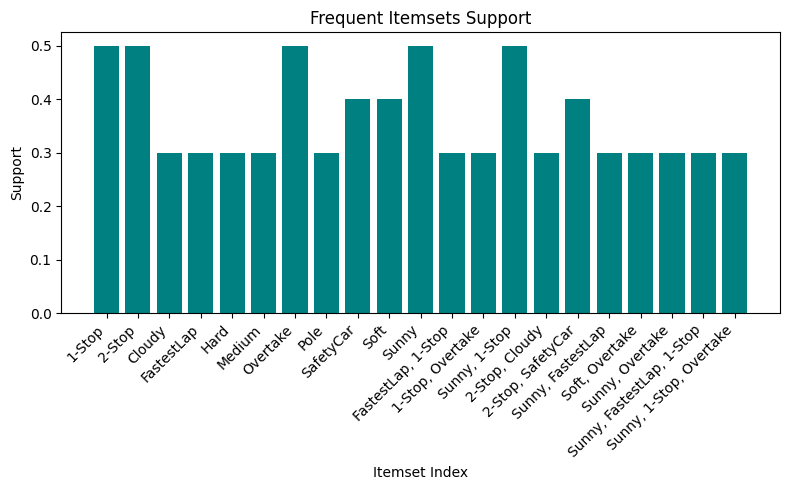

In [ ]:
# (d) Frequent itemsets support
plt.figure(figsize=(8,5))
plt.bar(range(len(frequent_itemsets)), frequent_itemsets['support'], color="teal")
plt.title("Frequent Itemsets Support")
plt.xlabel("Itemset Index")
plt.ylabel("Support")
plt.xticks(range(len(frequent_itemsets)), [", ".join(map(str, item)) for item in frequent_itemsets['itemsets']], rotation=45, ha="right")
plt.tight_layout()
plt.show()


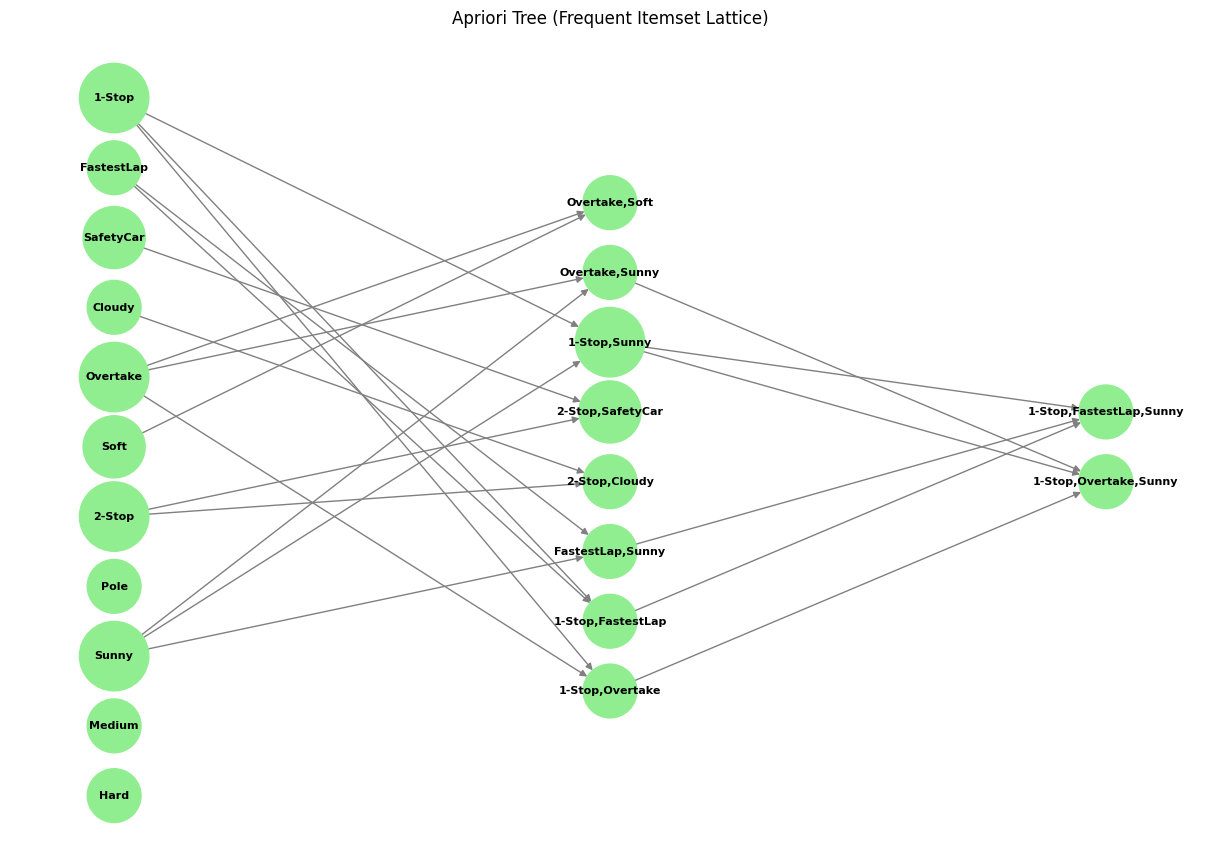

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Apriori Tree Visualization (Fixed to look like a Tree)
# -----------------------------
G = nx.DiGraph()

# Add nodes for each frequent itemset
for idx, row in frequent_itemsets.iterrows():
    itemset = tuple(sorted(row['itemsets']))
    G.add_node(itemset, support=row['support'], level=len(itemset))  # keep track of levels

# Add edges (if one itemset is subset of another)
for parent in G.nodes():
    for child in G.nodes():
        if set(parent).issubset(set(child)) and len(child) == len(parent) + 1:
            G.add_edge(parent, child)

# Use hierarchical layout (Graphviz)
try:
    from networkx.drawing.nx_agraph import graphviz_layout
    pos = graphviz_layout(G, prog="dot")  # "dot" arranges nodes as a tree
except:
    # fallback: multipartite layout (less pretty, but tree-like)
    pos = nx.multipartite_layout(G, subset_key="level")

# Draw graph
plt.figure(figsize=(12,8))
nx.draw(
    G, pos,
    with_labels=True,
    labels={n: ",".join(n) for n in G.nodes()},
    node_size=[5000*G.nodes[n]['support'] for n in G.nodes()],
    node_color="lightgreen",
    font_size=8,
    font_weight="bold",
    edge_color="gray",
    arrows=True
)
plt.title("Apriori Tree (Frequent Itemset Lattice)")
plt.show()